## データ download (2.2-6$R_s$)

SOHO/LASCO C2データは、VSO (Virtual Solar Observatory) を介して、または他のデータプロバイダからFidoを通じて取得できます。LASCO C2データはレベル0.5 (LZ) FITSファイルとして提供されることがあり、その場合、ファイル名がシーケンシャルな整数であるため、img_hdr.txtファイルが時刻同定に重要となります。

In [1]:
import astropy.units as u
from astropy.time import Time
from sunpy.net import Fido, attrs as a
import pathlib
import os

def download_soho_lasco_c2(date_str: str, time_str: str, time_window_start: int, time_window_end: int):
    """
    SOHO/LASCO C2のLevel 1データを指定された日時の±30分の範囲で検索し、
    指定されたディレクトリにダウンロードする関数。

    Args:
        date_str (str): 日付 (YYYYMMDD形式、例: "20230101")
        time_str (str): 時刻 (HH:MM形式、例: "12:00", UTCを想定)
    """
    # 1. ダウンロード先のディレクトリを定義
    download_dir_str = r"D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata"
    download_path = pathlib.Path(download_dir_str)

    # 2. ダウンロードディレクトリが存在しない場合は作成
    try:
        download_path.mkdir(parents=True, exist_ok=True)
        print(f"ℹ️ Download directory set to: {download_path}")
        if not os.access(download_dir_str, os.W_OK):
            print(f"⚠️ Warning: No write permissions for the directory: {download_dir_str}")
            print("   Please check directory permissions.")
    except Exception as e:
        print(f"❌ Error creating download directory {download_path}: {e}")
        print("   Please check the path and permissions. Exiting.")
        return

    # 3. 対象時刻と時間窓を定義
    try:
        year = date_str[0:4]
        month = date_str[4:6]
        day = date_str[6:8]

        if len(time_str) == 5:  # HH:MM
            time_str_full = f"{time_str}:00"
        elif len(time_str) == 8:  # HH:MM:SS
            time_str_full = time_str
        else:
            raise ValueError("Time format should be HH:MM or HH:MM:SS")

        target_time_iso_str = f"{year}-{month}-{day}T{time_str_full}"
        target_time = Time(target_time_iso_str, format='isot', scale='utc')
        
        time_window = a.Time(target_time - time_window_start*u.minute, target_time + time_window_end*u.minute)
        print(f"⏳ Target time window (UTC): {time_window.start.iso} to {time_window.end.iso}")

    except ValueError as ve:
        print(f"❌ Error parsing date/time: {ve}")
        print("   Please provide date as YYYYMMDD and time as HH:MM or HH:MM:SS.")
        return
    except Exception as e:
        print(f"❌ An unexpected error occurred during time processing: {e}")
        return

    # 4. SOHO/LASCO C2 Level 1 データを検索
    print("\n📡 Attempting to query for SOHO/LASCO C2 data...")
    lasco_fido_query = None 
    try:
        # Requesting Level 1 data (calibrated data).
        # If you specifically need a "Level 1.5" and know it's available via VSO
        # with that identifier, you could try a.Level(1.5) or a.Level('1.5').
        # However, Level 1 is the standard calibrated data for LASCO.
        query_attrs = [
            time_window,
            a.Instrument.lasco,
            a.Detector.c2,
            a.Level(1) 
        ]
        
        print(f"ℹ️ Requesting Level 1 data for SOHO/LASCO C2.")
        lasco_fido_query = Fido.search(*query_attrs)
        
        print("\n🔍 Fido Query Results:")
        # print(lasco_fido_query) # Uncomment to see the full query response table

        if lasco_fido_query is None or lasco_fido_query.file_num == 0:
            print(f"   ⚠️ No Level 1 data found for SOHO/LASCO C2 in the given time window.")
            print(f"      Consider broadening the time window or checking data availability directly from archives (e.g., SOHO Science Archive at ESA, MEDOC).")
            print(f"      If Level 0.5 (less processed, 'raw') data is acceptable, you can change a.Level(1) to a.Level(0.5) in the code.")
            return

        total_files_found = lasco_fido_query.file_num
        print(f"   Total Level 1 files found: {total_files_found}")

        for i, client_response in enumerate(lasco_fido_query):
            client_name = "Unknown Client"
            if hasattr(client_response, 'client') and client_response.client is not None:
                client_name = str(type(client_response.client)).split('.')[-1].replace("'>","")
            elif hasattr(type(client_response), '__name__'):
                client_name = type(client_response).__name__
            
            num_files_from_client = len(client_response)
            print(f"     Results from Provider/Client {i+1} ({client_name}): {num_files_from_client} files")
        
        # 5. ダウンロード処理
        if total_files_found > 0:
            print(f"\n📥 Attempting to download {total_files_found} files to: {download_path}")
            downloaded_files = Fido.fetch(lasco_fido_query, path=str(download_path), overwrite=False) 

            if downloaded_files:
                print(f"\n✅ Successfully downloaded {len(downloaded_files)} new files:")
                for f_path in downloaded_files:
                    print(f"     - {f_path}")
                if len(downloaded_files) < total_files_found:
                    print(f"   ℹ️ Note: {total_files_found - len(downloaded_files)} file(s) might have already existed in the directory and were skipped (overwrite=False).")
            elif total_files_found > 0: 
                print("\n   No new files were downloaded. All queried files might already exist in the target directory.")
                print(f"   Please check the directory: {download_path}")
        else: # Should be caught by the check above, but as a fallback.
            print("\n   No files found to download based on the query.")

    except Exception as e:
        print(f"\n❌ An error occurred during SOHO/LASCO C2 data query or download: {e}")
        if lasco_fido_query is not None:
            print("   Current query object state (if available):")
            # print(lasco_fido_query) 
        print("   Please check the error message, your internet connection, and the query parameters.")

# --- 関数の使用例 ---
if __name__ == '__main__':
    # ダウンロードしたい日付と時刻 (UTC) を指定してください
    test_date = "20220613" 
    test_time = "03:10"    

    print(f"🚀 Starting SOHO/LASCO C2 (Level 1) data download for {test_date} around {test_time} UTC...")
    download_soho_lasco_c2(test_date, test_time, time_window_start=90, time_window_end=90)
    print("\n🏁 Download process finished.")

d:\wsl\home\kinno-7010\Research\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Starting SOHO/LASCO C2 (Level 1) data download for 20220613 around 03:10 UTC...
ℹ️ Download directory set to: D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata
⏳ Target time window (UTC): 2022-06-13 01:40:00.000 to 2022-06-13 04:40:00.000

📡 Attempting to query for SOHO/LASCO C2 data...
ℹ️ Requesting Level 1 data for SOHO/LASCO C2.

🔍 Fido Query Results:
   Total Level 1 files found: 17
     Results from Provider/Client 1 (VSOClient): 17 files

📥 Attempting to download 17 files to: D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata


Files Downloaded:  35%|███▌      | 6/17 [00:01<00:01,  5.93file/s]

Files Downloaded:  76%|███████▋  | 13/17 [00:01<00:00, 10.21file/s]




Files Downloaded:  94%|█████████▍| 16/17 [00:02<00:00,  5.67file/s]



Files Downloaded: 100%|██████████| 17/17 [00:04<00:00,  3.63file/s]


✅ Successfully downloaded 17 new files:
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862832.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862833.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862834.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862835.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862836.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862837.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862838.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862839.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862840.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862841.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862842.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862843.fts
     - D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862844.f

# plot

## 初期設定・関数

In [6]:
import matplotlib.pyplot as plt
import sunpy.map
from sunpy.coordinates import get_horizons_coord
from sunpy.sun import constants
from astropy.visualization import AsinhStretch
from astropy.visualization.mpl_normalize import ImageNormalize
import numpy as np
import astropy.units as u
from pathlib import Path
from tqdm import tqdm
import imageio.v2 as imageio
import io
from astropy.time import Time


# create_corrected_lasco_map関数は変更なく、そのまま使用します
def create_corrected_lasco_map(filepath: str | Path) -> sunpy.map.Map:
    """SOHO/LASCOのFITSファイルを読み込み、観測者位置と太陽視半径を補正したMapを生成"""
    print(f"'{Path(filepath).name}' を読み込んでいます...")
    lasco_map_raw = sunpy.map.Map(filepath)
    print("SOHOの正確な位置をJPL HORIZONSから取得中...")
    observer_coord = get_horizons_coord('SOHO', lasco_map_raw.date)
    new_meta = lasco_map_raw.meta.copy()
    new_meta['hgln_obs'] = observer_coord.lon.value
    new_meta['hglt_obs'] = observer_coord.lat.value
    dsun_obs = observer_coord.radius
    new_meta['dsun_obs'] = dsun_obs.to('m').value
    rsun_physical = constants.get('radius')
    rsun_arc = np.arctan(rsun_physical / dsun_obs).to(u.arcsec).value
    new_meta['rsun_arc'] = rsun_arc
    print("メタデータの補正が完了しました。")
    corrected_map = sunpy.map.Map(lasco_map_raw.data, new_meta)
    return corrected_map


# ★★★ ここからがシンプルに書き換えた描画関数 ★★★
def plot_lasco_with_integer_contours(lasco_map: sunpy.map.Map, ax=None, show_grid: bool = True):
    """
    Mapオブジェクトをプロットし、太陽半径の整数倍の等高線を描画する。

    Args:
        lasco_map (sunpy.map.Map): プロットするMapオブジェクト。
        ax (matplotlib.axes.Axes, optional): プロット先のAxes。指定しない場合は新規作成する。
        show_grid (bool, optional): 背景の直交グリッドを表示するかどうか。
    """
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(1, 1, 1, projection=lasco_map)

    # 輝度のノーマライゼーション
    norm = ImageNormalize(
        vmin=np.percentile(lasco_map.data, 0.1),
        vmax=np.percentile(lasco_map.data, 99.9),
        stretch=AsinhStretch(a=0.1)
    )

    # LASCO画像のプロット
    lasco_map.plot(axes=ax, cmap='sdoaia304', norm=norm, annotate=False)
    
    # 太陽本体のリムを描画 (1R☉)
    lasco_map.draw_limb(axes=ax, color='white', linestyle='solid', linewidth=1)
    
    # --- 等高線描画のための準備 ---
    # 1. 各ピクセルの座標グリッドから半径マップを生成 (単位: R_sun)
    x, y = np.meshgrid(*[np.arange(v.value) for v in lasco_map.dimensions]) * u.pix
    coords = lasco_map.pixel_to_world(x, y)
    rsun_arcsecs = lasco_map.meta['rsun_arc']
    radius_map = np.sqrt(coords.Tx**2 + coords.Ty**2) / (rsun_arcsecs * u.arcsec)
    
    # --- 等高線の描画 ---
    # 画像に収まる最大の整数半径まで、2R☉から等高線を引く
    max_radius = 6
    int_levels = np.arange(2, max_radius + 1)
    
    if len(int_levels) > 0:
        ax.contour(radius_map.value, levels=int_levels, colors='white', 
                   linewidths=1, linestyles='--', alpha=0.7)

    # 太陽中心のマーカー
    ax.plot(0, 0, '+', color='yellow', markersize=12, markeredgewidth=1.5,
            transform=ax.get_transform('world'))

    # 背景グリッドと軸ラベル、タイトル
    ax.grid(show_grid, color='white', linestyle=':', alpha=0.5)
    ax.set_xlabel('Solar-X (arcsec)')
    ax.set_ylabel('Solar-Y (arcsec)')
    ax.set_title(f'SOHO/LASCO-C2 | {lasco_map.date.iso}')
    
    
def find_files_in_time_range(directory: Path, start_time: str, end_time: str) -> list[Path]:
    """
    指定されたディレクトリと時間範囲に一致するFITSファ
    イルのリストを返す。
    sunpy.map.Mapを使って確実に時刻を取得する。
    """
    print(f"ディレクトリ '{directory}' 内の.ftsファイルを検索しています...")
    all_files = sorted(directory.glob('*.fts'))
    
    t_start = Time(start_time)
    t_end = Time(end_time)
    
    filtered_files = []
    print("各ファイルを読み込み、時間範囲内か確認しています（時間がかかる場合があります）...")
    for f in tqdm(all_files, desc="ファイルフィルタリング"):
        try:
            # ★★★ 修正箇所: sunpy.map.Mapでファイル全体を読み込む ★★★
            m = sunpy.map.Map(f)
            # .date属性から直接、正確な時刻（Timeオブジェクト）を取得
            file_time = m.date
            
            if t_start <= file_time <= t_end:
                filtered_files.append(f)
        except Exception as e:
            # 読み込みに失敗したファイルはスキップ
            print(f"ファイル {f.name} の読み込み/解析中にエラー: {e}")
            continue
            
    return filtered_files


def plot_difference_map(diff_map: sunpy.map.Map, base_map_date: Time, ax=None, show_grid: bool = True):
    """
    差分Mapオブジェクトをプロットする。カラーマップやノーマライゼーションは差分表示に最適化。
    """
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(1, 1, 1, projection=diff_map)

    # 差分データ用のノーマライゼーション（ゼロ中心で対称）
    vmax = np.percentile(np.abs(diff_map.data), 99.5) # 99.5%点の絶対値を取得
    norm = ImageNormalize(vmin=-vmax, vmax=vmax)

    # 差分画像なので、発散するカラーマップ（'gray'や'bwr'など）が適している
    diff_map.plot(axes=ax, cmap='gray', norm=norm, annotate=False)
    
    # 太陽本体のリムと等高線は空間的な参照のために描画する
    diff_map.draw_limb(axes=ax, color='lime', linestyle='solid', linewidth=1)
    
    x, y = np.meshgrid(*[np.arange(v.value) for v in diff_map.dimensions]) * u.pix
    coords = diff_map.pixel_to_world(x, y)
    rsun_arcsecs = diff_map.meta['rsun_arc']
    radius_map = np.sqrt(coords.Tx**2 + coords.Ty**2) / (rsun_arcsecs * u.arcsec)
    
    max_radius = 6
    int_levels = np.arange(2, max_radius + 1)
    
    if len(int_levels) > 0:
        ax.contour(radius_map.value, levels=int_levels, colors='lime', 
                   linewidths=1, linestyles='--', alpha=0.5)

    ax.plot(0, 0, '+', color='yellow', markersize=12, markeredgewidth=1.5,
            transform=ax.get_transform('world'))

    ax.grid(show_grid, color='white', linestyle=':', alpha=0.5)
    ax.set_xlabel('Solar-X (arcsec)')
    ax.set_ylabel('Solar-Y (arcsec)')
    
    # タイトルに差分元と差分先の時刻を両方表示する
    time_delta_minutes = (diff_map.date - base_map_date).to(u.min).value
    ax.set_title(
        f'SOHO/LASCO-C2 (Running Difference)\n'
        f'{base_map_date.strftime("%Y-%m-%d %H:%M:%S")} - {diff_map.date.strftime("%Y-%m-%d %H:%M:%S")}'
    )

def create_lasco_movie(file_list: list[Path], output_path: Path, fps: int):
    """ファイルリストからフレームを生成し、動画ファイルとして保存する"""
    frames = []
    print("各フレームをメモリ上にレンダリングしています...")
    for filepath in tqdm(file_list, desc="フレーム生成"):
        try:
            # create_corrected_lasco_mapは重いので、フィルタリングで読み込んだMapを再利用したいが、
            # 現状のコード構成では、ここで再度読み込む必要がある。
            current_map = create_corrected_lasco_map(filepath)
            fig = plt.figure(figsize=(8, 8))
            ax = fig.add_subplot(1, 1, 1, projection=current_map)
            plot_lasco_with_integer_contours(current_map, ax, show_grid=False)
            
            buf = io.BytesIO()
            plt.savefig(buf, format='png', dpi=150)
            buf.seek(0)
            image_from_plot = imageio.imread(buf)
            buf.close()
            
            frames.append(image_from_plot)
            plt.close(fig)
        except Exception as e:
            print(f"ファイル {filepath.name} の処理中にエラーが発生しました: {e}")
            plt.close('all')
            continue

    if not frames:
        print("有効なフレームが生成されなかったため、動画は作成されませんでした。")
        return

    print(f"\n全{len(frames)}フレームをレンダリングしました。動画に変換します...")
    try:
        imageio.mimwrite(output_path, frames, fps=fps, codec='libx264', quality=8)
        print(f"\n動画ファイル '{output_path}' が正常に作成されました。")
    except Exception as e:
        print(f"\n動画の保存中にエラーが発生しました: {e}")
        
        
def create_lasco_running_difference_movie(file_list: list[Path], output_path: Path, fps: int):
    """
    ファイルリストからランニング・ディファレンス（差分）画像を生成し、動画として保存する。
    """
    if len(file_list) < 2:
        print("差分動画を作成するには少なくとも2つのファイルが必要です。")
        return
        
    frames = []
    print("連続するフレーム間の差分を計算し、レンダリングしています...")
    
    # 差分を取るため、ループは(リストの長さ - 1)回実行する
    for i in tqdm(range(len(file_list) - 1), desc="差分フレーム生成"):
        filepath_i = file_list[i]
        filepath_i_plus_1 = file_list[i+1]
        
        try:
            # 連続する2つの時刻のマップを読み込む
            map_i = create_corrected_lasco_map(filepath_i)
            map_i_plus_1 = create_corrected_lasco_map(filepath_i_plus_1)

            # データ配列の差分を計算
            # メタデータは後の時刻のものを引き継ぐ
            diff_data = map_i_plus_1.data - map_i.data
            diff_map = sunpy.map.Map(diff_data, map_i_plus_1.meta)
            
            # 差分マップをプロット
            fig = plt.figure(figsize=(8, 8))
            ax = fig.add_subplot(1, 1, 1, projection=diff_map)
            plot_difference_map(diff_map, base_map_date=map_i.date, ax=ax, show_grid=False)
            
            # プロットした画像をメモリ上のバッファに保存
            buf = io.BytesIO()
            plt.savefig(buf, format='png', dpi=150)
            buf.seek(0)
            frames.append(imageio.imread(buf))
            buf.close()
            plt.close(fig)

        except Exception as e:
            print(f"ファイル {filepath_i.name} と {filepath_i_plus_1.name} の処理中にエラー: {e}")
            plt.close('all') # エラー時に開いているFigureをすべて閉じる
            continue

    if not frames:
        print("有効なフレームが生成されなかったため、動画は作成されませんでした。")
        return

    print(f"\n全{len(frames)}フレームの差分画像をレンダリングしました。動画に変換します...")
    try:
        imageio.mimwrite(output_path, frames, fps=fps, codec='libx264', quality=8)
        print(f"\n動画ファイル '{output_path}' が正常に作成されました。")
    except Exception as e:
        print(f"\n動画の保存中にエラーが発生しました: {e}")



## プロット作成

'22862841.fts' を読み込んでいます...
SOHOの正確な位置をJPL HORIZONSから取得中...


2025-06-09 21:02:28 - sunpy - INFO: Obtained JPL HORIZONS location for SOHO (spacecraft) (-21)        
2025-06-09 21:02:28 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2025-06-09 21:02:28 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Obtained JPL HORIZONS location for SOHO (spacecraft) (-21)         [sunpy.coordinates.ephemeris]
メタデータの補正が完了しました。
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


2025-06-09 21:02:28 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


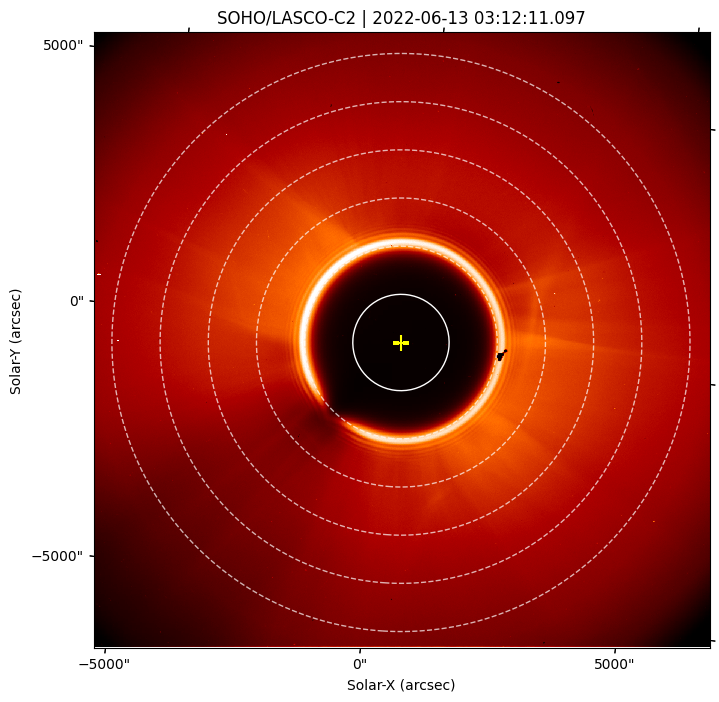

In [3]:


# --- メイン実行ブロック ---
if __name__ == '__main__':
    FITS_FILE_PATH = r'D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata\22862841.fts'

    # --- ステップ 1: データの準備 ---
    corrected_soho_map = create_corrected_lasco_map(FITS_FILE_PATH)
    
    # --- ステップ 2: プロットの実行 ---
    # シンプルになった新しい描画関数を呼び出す
    plot_lasco_with_integer_contours(corrected_soho_map, show_grid=False)

    # --- ステップ 3: 表示 ---
    plt.show()

## 動画作成

In [27]:
if __name__ == '__main__':
    # --- 1. パラメータ設定 ---
    START_TIME = '2022-06-13T02:00:00'
    END_TIME   = '2022-06-13T04:30:00'
    
    BASE_DIR = Path(r'D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata')
    OUTPUT_DIR = Path(r'D:\wsl\home\kinno-7010\Research\SOHO\output')
    
    # 出力ファイル名に時間範囲を含めると分かりやすい
    output_filename_str = f"lasco_c2_{Time(START_TIME).strftime('%Y%m%d_%H%M%S')}-{Time(END_TIME).strftime('%H%M%S')}.mp4"
    OUTPUT_PATH = OUTPUT_DIR / output_filename_str
    FRAME_RATE = 5

    # --- 2. ファイルの検索 ---
    files_to_process = find_files_in_time_range(BASE_DIR, START_TIME, END_TIME)
    
    # --- 3. 動画の作成 ---
    if files_to_process:
        print(f"時間範囲({START_TIME} - {END_TIME})に一致した {len(files_to_process)}個のファイルで動画を作成します。")
        create_lasco_movie(files_to_process, OUTPUT_PATH, FRAME_RATE)
    else:
        print("指定された時間範囲に該当するファイルは見つかりませんでした。")

ディレクトリ 'D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata' 内の.ftsファイルを検索しています...
各ファイルを読み込み、時間範囲内か確認しています（時間がかかる場合があります）...


ファイルフィルタリング: 100%|██████████| 15/15 [00:00<00:00, 33.22it/s]


時間範囲(2022-06-13T02:00:00 - 2022-06-13T04:30:00)に一致した 14個のファイルで動画を作成します。
各フレームをメモリ上にレンダリングしています...


フレーム生成:   0%|          | 0/14 [00:00<?, ?it/s]

'22862834.fts' を読み込んでいます...
SOHOの正確な位置をJPL HORIZONSから取得中...
INFO: Obtained JPL HORIZONS location for SOHO (spacecraft) (-21)         [sunpy.coordinates.ephemeris]
メタデータの補正が完了しました。
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


...

'22862846.fts' を読み込んでいます...
SOHOの正確な位置をJPL HORIZONSから取得中...
INFO: Obtained JPL HORIZONS location for SOHO (spacecraft) (-21)         [sunpy.coordinates.ephemeris]
メタデータの補正が完了しました。
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


フレーム生成:  93%|█████████▎| 13/14 [00:24<00:01,  1.92s/it]

'22862847.fts' を読み込んでいます...
SOHOの正確な位置をJPL HORIZONSから取得中...
INFO: Obtained JPL HORIZONS location for SOHO (spacecraft) (-21)         [sunpy.coordinates.ephemeris]
メタデータの補正が完了しました。
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


フレーム生成: 100%|██████████| 14/14 [00:26<00:00,  1.86s/it]



全14フレームをレンダリングしました。動画に変換します...

動画ファイル 'D:\wsl\home\kinno-7010\Research\SOHO\output\lasco_c2_20220613_020000-043000.mp4' が正常に作成されました。


## difference

### プロット

### 動画

In [7]:
if __name__ == '__main__':
    # --- 1. パラメータ設定 ---
    START_TIME = '2022-06-13T02:00:00'
    END_TIME   = '2022-06-13T04:30:00'
    
    # 注意: パスはご自身の環境に合わせて修正してください
    

    # --- 2. ファイルの検索 ---
    files_to_process = find_files_in_time_range(BASE_DIR, START_TIME, END_TIME)
    
    # --- 3. 動画の作成 ---
    if files_to_process:
        print(f"時間範囲({START_TIME} - {END_TIME})に一致した {len(files_to_process)}個のファイルで動画を作成します。")

        # --- 3b. 差分動画を作成する場合 (新規) ---
        diff_output_filename_str = f"lasco_c2_running_difference_{Time(START_TIME).strftime('%Y%m%d_%H%M%S')}-{Time(END_TIME).strftime('%H%M%S')}.mp4"
        OUTPUT_PATH_DIFF = OUTPUT_DIR / diff_output_filename_str
        create_lasco_running_difference_movie(files_to_process, OUTPUT_PATH_DIFF, FRAME_RATE)

    else:
        print("指定された時間範囲に該当するファイルは見つかりませんでした。")

ディレクトリ 'D:\wsl\home\kinno-7010\Research\SOHO\LASCO-C2_rawdata' 内の.ftsファイルを検索しています...
各ファイルを読み込み、時間範囲内か確認しています（時間がかかる場合があります）...


ファイルフィルタリング: 100%|██████████| 15/15 [00:00<00:00, 44.49it/s]


時間範囲(2022-06-13T02:00:00 - 2022-06-13T04:30:00)に一致した 14個のファイルで動画を作成します。
連続するフレーム間の差分を計算し、レンダリングしています...


差分フレーム生成:   0%|          | 0/13 [00:00<?, ?it/s]

'22862834.fts' を読み込んでいます...
SOHOの正確な位置をJPL HORIZONSから取得中...


...

INFO: Obtained JPL HORIZONS location for SOHO (spacecraft) (-21)         [sunpy.coordinates.ephemeris]
メタデータの補正が完了しました。
'22862847.fts' を読み込んでいます...
SOHOの正確な位置をJPL HORIZONSから取得中...


2025-06-09 21:11:25 - sunpy - INFO: Obtained JPL HORIZONS location for SOHO (spacecraft) (-21)        
2025-06-09 21:11:25 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2025-06-09 21:11:25 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2025-06-09 21:11:25 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Obtained JPL HORIZONS location for SOHO (spacecraft) (-21)         [sunpy.coordinates.ephemeris]
メタデータの補正が完了しました。
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


差分フレーム生成: 100%|██████████| 13/13 [00:31<00:00,  2.40s/it]


全11フレームの差分画像をレンダリングしました。動画に変換します...

動画の保存中にエラーが発生しました: [Errno 32] Broken pipe

FFMPEG COMMAND:
d:\wsl\home\kinno-7010\Research\.venv-win\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -y -f rawvideo -vcodec rawvideo -s 1200x1200 -pix_fmt rgba -r 5.00 -i - -an -vcodec libx264 -pix_fmt yuv420p -crf 10 -v warning D:\wsl\home\kinno-7010\Research\SOHO\output\lasco_c2_running_difference_20220613_020000-043000.mp4

FFMPEG STDERR OUTPUT:

